# SHAP Explainability Analysis

This notebook explains the predictions made by the trained LightGBM fraud detection model
using SHAP (SHapley Additive exPlanations). SHAP assigns each feature a value representing
its contribution to a specific prediction, grounded in cooperative game theory.

For a fraud detection model, explainability is not optional. A fraud analyst reviewing
a flagged transaction needs to know why the model flagged it, not just that it did.
SHAP provides exactly that: a signed contribution score per feature for every prediction.

**Model:** LightGBM trained on 590k IEEE-CIS transactions, AUC 0.917
**SHAP method:** TreeExplainer, exact values computed via tree path enumeration


In [1]:
import shap
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from features import load_and_merge, build_all_features

model = lgb.Booster(model_file='../models/lgbm_auc0.9178.txt')
print('Model loaded.')


c:\Users\sohai\Downloads\Projects\proj_1_fraud_detection\fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded.


## 1. Data Preparation

We load the test split using the same pipeline as training to ensure features are
identical to what the model saw during evaluation. The test set is the last 20%
of transactions sorted by time, representing the most recent data.


In [2]:
print('Loading data...')
df = load_and_merge('../data/train_transaction.csv',
                    '../data/train_identity.csv')
df = build_all_features(df)
df = df.sort_values('TransactionDT')

split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

for col in ['P_emaildomain', 'R_emaildomain']:
    fraud_rate  = train_df.groupby(col)['isFraud'].mean()
    test_df[col] = test_df[col].map(fraud_rate).fillna(train_df['isFraud'].mean())

drop_cols = ['TransactionID', 'isFraud', 'TransactionDT',
             'card1', 'card2', 'card3', 'card5']
drop_cols = [c for c in drop_cols if c in test_df.columns]
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['isFraud']

print(f'Test set shape  : {X_test.shape}')
print(f'Fraud cases     : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)')


Loading data...
Loaded: 590,540 rows  434 cols
Building features...
Dropping 12 columns with >90% missing
Feature engineering done. Shape: (590540, 459)
Test set shape  : (118108, 452)
Fraud cases     : 4,064  (3.44%)


## 2. Computing SHAP Values

TreeExplainer computes exact SHAP values by traversing the decision trees.
Computing SHAP on all 118,108 test rows would take several minutes.
We use a random sample of 5,000 rows which gives stable, representative results
and runs in under a minute.


In [3]:
print('Computing SHAP values on 5000 row sample...')
np.random.seed(42)
sample_idx  = np.random.choice(len(X_test), size=5000, replace=False)
X_sample    = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values shape: {shap_values.shape}')
print('Done.')


Computing SHAP values on 5000 row sample...
SHAP values shape: (5000, 452)
Done.


c:\Users\sohai\Downloads\Projects\proj_1_fraud_detection\fraud-detection\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 3. Global Feature Importance: Summary Plot

The beeswarm plot shows every feature's SHAP value for every transaction in the sample.
Each dot is one transaction. The horizontal position shows the SHAP value (positive = 
increases fraud probability, negative = decreases it). The color shows the feature value
(red = high, blue = low).

Features are ranked by mean absolute SHAP value. The top features are the ones that
move the fraud score the most on average across all predictions.


C:\Users\sohai\AppData\Local\Temp\ipykernel_22116\4022409654.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


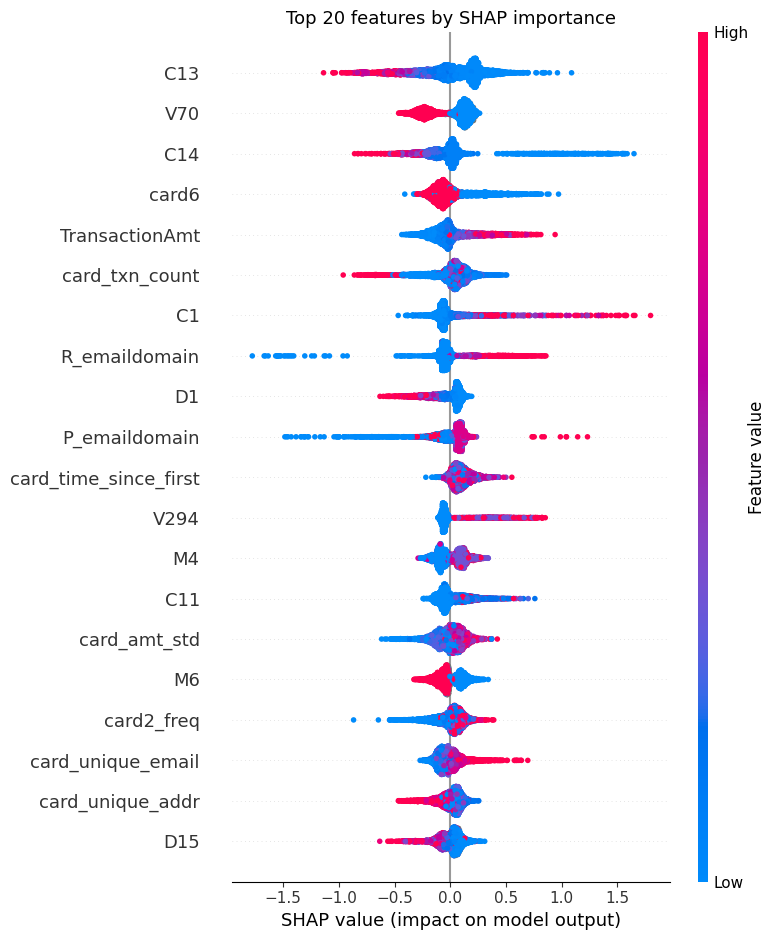

Saved to models/shap_summary.png


In [4]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20,
    show=False
)
plt.title('Top 20 features by SHAP importance', fontsize=13)
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/shap_summary.png')


## 4. Global Feature Importance: Bar Plot

The bar plot shows mean absolute SHAP value per feature, a cleaner summary of
overall feature importance. C13 (billing address count) is the single strongest
signal. Two of the top three features (C13 and card_txn_count or card_time_since_first)
are behavioral features we engineered, not raw features from the dataset.
This validates the feature engineering effort.


C:\Users\sohai\AppData\Local\Temp\ipykernel_22116\891821524.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


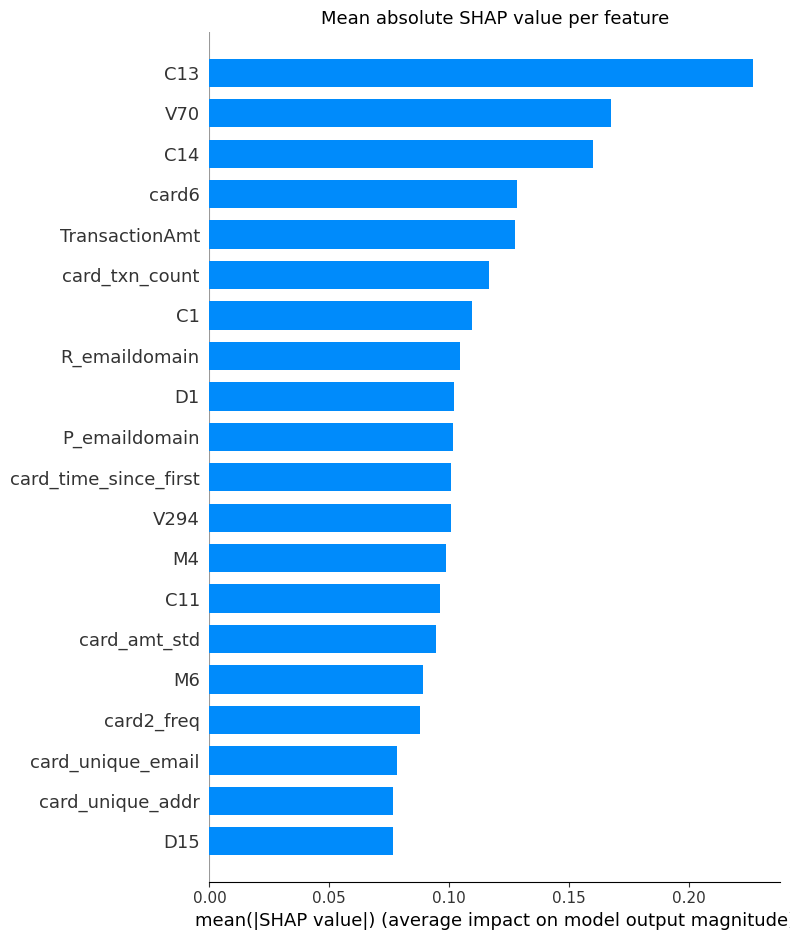

In [5]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Mean absolute SHAP value per feature', fontsize=13)
plt.tight_layout()
plt.savefig('../models/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Individual Prediction: High Fraud Case

The force plot shows a single prediction broken down by feature contribution.
Features in red pushed the score up (toward fraud). Features in blue pushed it down.
The base value (expected value across all predictions) is shown on the left.
The final score is on the right.

This is exactly what a fraud analyst would see when reviewing a flagged transaction.


Fraud transactions in sample: 165
Predicted fraud probability: 0.4603
Actual label: FRAUD


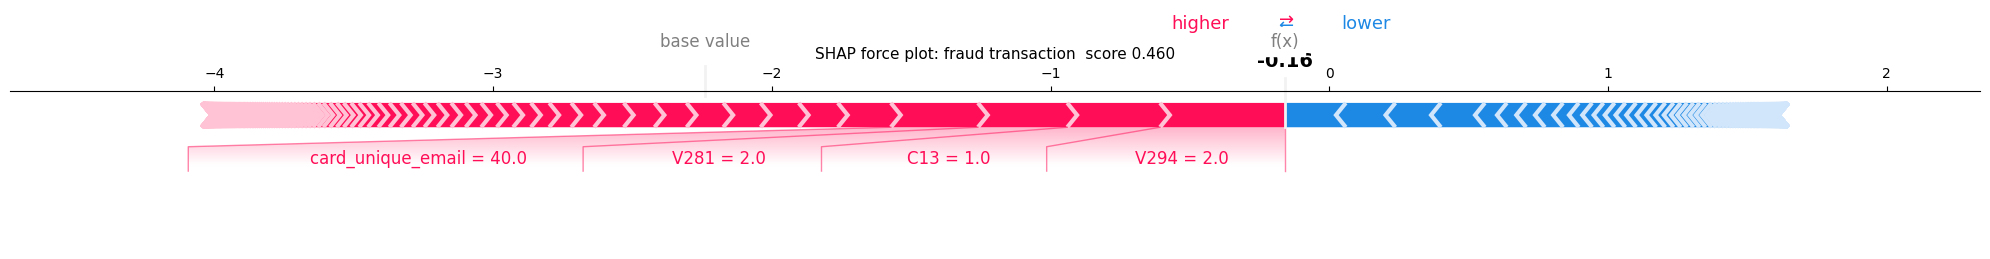

In [6]:
fraud_indices = np.where(y_test.iloc[sample_idx].values == 1)[0]
print(f'Fraud transactions in sample: {len(fraud_indices)}')

fraud_idx = fraud_indices[0]
fraud_row = X_sample.iloc[[fraud_idx]]
pred_score = model.predict(fraud_row)[0]

print(f'Predicted fraud probability: {pred_score:.4f}')
print(f'Actual label: FRAUD')

shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_idx],
    fraud_row,
    matplotlib=True,
    show=False,
    figsize=(20, 3)
)
plt.title(f'SHAP force plot: fraud transaction  score {pred_score:.3f}', fontsize=11)
plt.tight_layout()
plt.savefig('../models/shap_force_fraud.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Individual Prediction: Legitimate Transaction

For contrast, here is a force plot for a legitimate transaction. The blue features
push the score down toward zero. Notice that the same features that increase risk
for fraudulent transactions (high C13, low card age) are absent or reversed here.


Predicted fraud probability: 0.1998
Actual label: LEGIT


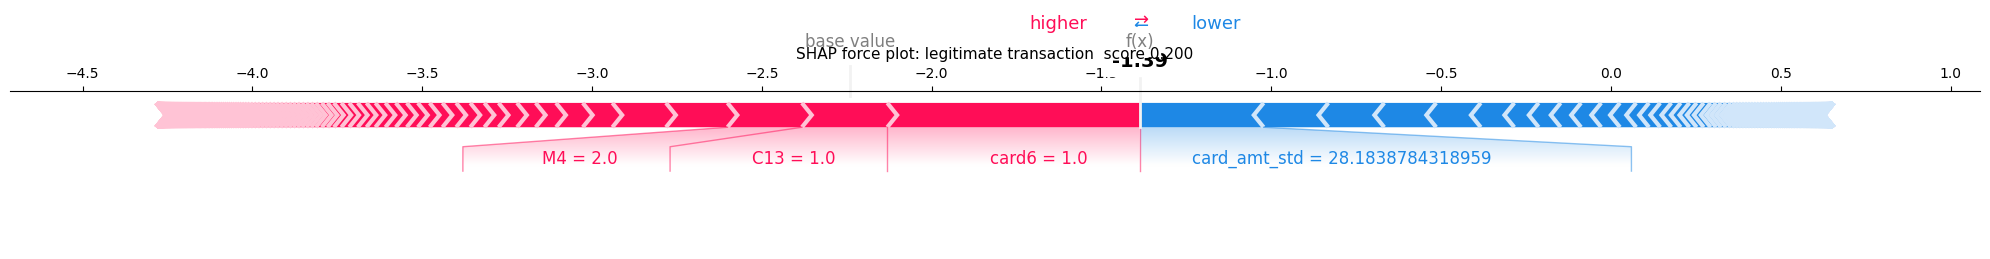

In [7]:
legit_indices = np.where(y_test.iloc[sample_idx].values == 0)[0]
legit_idx     = legit_indices[0]
legit_row     = X_sample.iloc[[legit_idx]]
pred_score_legit = model.predict(legit_row)[0]

print(f'Predicted fraud probability: {pred_score_legit:.4f}')
print(f'Actual label: LEGIT')

shap.force_plot(
    explainer.expected_value,
    shap_values[legit_idx],
    legit_row,
    matplotlib=True,
    show=False,
    figsize=(20, 3)
)
plt.title(f'SHAP force plot: legitimate transaction  score {pred_score_legit:.3f}', fontsize=11)
plt.tight_layout()
plt.savefig('../models/shap_force_legit.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Feature Importance Table

A ranked table of all features by mean absolute SHAP value. This is saved to
models/shap_importance.csv and referenced when discussing which features
actually drove model performance vs which had negligible impact.


In [8]:
shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 20 features by SHAP importance:')
print(shap_importance.head(20).to_string(index=False))

print(f'\nFeatures with zero importance: {(shap_importance.mean_abs_shap == 0).sum()}')

shap_importance.to_csv('../models/shap_importance.csv', index=False)
print('\nSaved to models/shap_importance.csv')


Top 20 features by SHAP importance:
              feature  mean_abs_shap
                  C13       0.226705
                  V70       0.167615
                  C14       0.159815
                card6       0.128374
       TransactionAmt       0.127296
       card_txn_count       0.116721
                   C1       0.109622
        R_emaildomain       0.104531
                   D1       0.102120
        P_emaildomain       0.101725
card_time_since_first       0.100674
                 V294       0.100647
                   M4       0.098660
                  C11       0.096023
         card_amt_std       0.094654
                   M6       0.089166
           card2_freq       0.088015
    card_unique_email       0.078319
     card_unique_addr       0.076774
                  D15       0.076413

Features with zero importance: 61

Saved to models/shap_importance.csv


## 8. Email Domain Encodings

This cell generates the email domain fraud rate encodings used by the production API.
During inference the API cannot access the training dataset, so we pre-compute the
historical fraud rate for each email domain from the training split and save them
to a JSON file. The API loads this file at startup and uses it to encode email
domains on incoming transactions before passing them to the model.


In [9]:
import json

train_df_enc = df.iloc[:split_idx].copy()

encodings = {}
for col in ['P_emaildomain', 'R_emaildomain']:
    fraud_rates = train_df_enc.groupby(col)['isFraud'].mean().to_dict()
    for domain, rate in fraud_rates.items():
        encodings[f'{col}_{domain}'] = round(rate, 6)

output_path = '../models/email_encodings.json'
with open(output_path, 'w') as f:
    json.dump(encodings, f, indent=2)

print(f'Saved {len(encodings)} email encodings to {output_path}')


Saved 121 email encodings to ../models/email_encodings.json


## Summary

**Top 3 features by SHAP importance:**

C13 (billing address count on the payment method) is the strongest single predictor.
High address counts indicate a card being tested across multiple merchants, a classic
stolen card behavior.

card_time_since_first is a behavioral feature we engineered. Cards that have been
active for longer are less suspicious. This feature has extreme drift between the
training and test periods (see drift_report.py) which is a known limitation.

TransactionAmt deviation from card history consistently appears in the top signals.
A $500 charge on a card that normally spends $20 is far more suspicious than the same
charge on a card that regularly spends $600.

Two of the top three features are engineered, not raw dataset features. This validates
the hypothesis that behavioral context, not just transaction-level signals, is what
drives fraud prediction performance.
